# Full Inference Pipeline

Apply all 9 trained models (3 tag groups × 3 optimization types) to the inference dataset.

Models:
- **Tag Groups**: Genre, Mood, Situation
- **Optimization Types**: F1, Precision, Recall

This notebook generates predictions and displays results organized by tag group and optimization type.

In [1]:
# Automatically reload imported modules before executing code
%load_ext autoreload
%autoreload 2

In [5]:
from nbutils import setup_path, display_polars
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl
from pathlib import Path

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

setup_path()
pl.Config.set_tbl_rows(50)

polars.config.Config

## Configuration

In [17]:
# Model configuration
TAG_GROUPS = ["Genre", "Mood", "Situation"]
METRICS = ["f1", "precision", "recall"]
MODEL_DIR = Path("../models")

# Feature configuration (same as training)
EXCLUDE_COLS = [
    "song_path", "harmonic_percussive_ratio", "percussive_strength",
    "tonnetz_mean_0", "tonnetz_mean_1", "tonnetz_mean_2", "tonnetz_mean_3", "tonnetz_mean_4", "tonnetz_mean_5",
    "tonnetz_std_0", "tonnetz_std_1", "tonnetz_std_2", "tonnetz_std_3", "tonnetz_std_4", "tonnetz_std_5"
]

print(f"Total models to load: {len(TAG_GROUPS)} × {len(METRICS)} = {len(TAG_GROUPS) * len(METRICS)}")

Total models to load: 3 × 3 = 9


## Load All Models

Load all 9 trained models from the models directory.

In [18]:
from models import load_model

# Dictionary to store all loaded models
# Key format: (tag_group, metric)
all_models = {}

print("Loading models...\n")
print("="*80)

for tag_group in TAG_GROUPS:
    for metric in METRICS:
        # Find the latest model file for this tag_group and metric
        pattern = f"xgboost_{tag_group}_{metric}_*_model.pkl"
        model_files = sorted(MODEL_DIR.glob(pattern))
        
        if not model_files:
            print(f"⚠️  No model found for {tag_group} - {metric}")
            continue
        
        model_file = model_files[-1]  # Get the latest
        
        # Load model
        model_data = load_model(str(model_file))
        all_models[(tag_group, metric)] = model_data
        
        # Get F1 score from config metrics
        f1_score = model_data['config'].get('metrics', {}).get('macro_f1', 0)
        print(f"✓ Loaded {tag_group:12} {metric:9} - F1: {f1_score:.4f}")

print("="*80)
print(f"\nSuccessfully loaded {len(all_models)} models")

Loading models...


MODEL LOADED SUCCESSFULLY
Model name: xgboost_Genre_f1
Tag group: Genre
Number of labels: 22
Saved on: 2025-10-18T11:15:19.690348

Loaded components:
  Model: ✓
  Thresholds: ✓
  Scaler: ✓
  PCA: ✗

Stored metrics:
  macro_precision: 0.5181
  macro_recall: 0.5985
  macro_f1: 0.5055
  weighted_precision: 0.5466
  weighted_recall: 0.7453
  weighted_f1: 0.5970
  optimization_metric: f1

✓ Loaded Genre        f1        - F1: 0.5055

MODEL LOADED SUCCESSFULLY
Model name: xgboost_Genre_precision
Tag group: Genre
Number of labels: 22
Saved on: 2025-10-18T11:15:19.654936

Loaded components:
  Model: ✓
  Thresholds: ✓
  Scaler: ✓
  PCA: ✗

Stored metrics:
  macro_precision: 0.7047
  macro_recall: 0.1489
  macro_f1: 0.2301
  weighted_precision: 0.8552
  weighted_recall: 0.1708
  weighted_f1: 0.2652
  optimization_metric: precision

✓ Loaded Genre        precision - F1: 0.2301

MODEL LOADED SUCCESSFULLY
Model name: xgboost_Genre_recall
Tag group: Genre
Number of labels: 22
Sav

## Load Inference Dataset

Load songs that need to be tagged (inference dataset).

In [19]:
from pyrekordbox import Rekordbox6Database
from utils import get_clean_songs

# Load Rekordbox database for song metadata
db = Rekordbox6Database()
songs_df = get_clean_songs(db, rename=True)

# Load inference features
inference_df = pl.read_parquet("../data/song_inference.parquet")

print(f"Loaded {len(inference_df)} songs for inference")
print(f"\nInference dataset columns: {inference_df.columns[:10]}...")

[12:16:10] pyrekordbox.db6.database:WARNING  - Rekordbox is running!


Loaded 724 songs for inference

Inference dataset columns: ['song_id', 'song_path', 'mel_spec_mean_0', 'mel_spec_mean_1', 'mel_spec_mean_2', 'mel_spec_mean_3', 'mel_spec_mean_4', 'mel_spec_mean_5', 'mel_spec_mean_6', 'mel_spec_mean_7']...


## Prepare Features

Extract and scale features for each tag group model.

In [20]:
# Get feature columns (excluding metadata and problematic features)
feature_cols = [
    col for col in inference_df.columns 
    if col not in EXCLUDE_COLS + ["song_id", "song_path"]
]

print(f"Using {len(feature_cols)} features for inference")
print(f"\nFirst 10 features: {feature_cols[:10]}")

# Extract features
X_inference = inference_df.select(["song_id"] + feature_cols)

# We'll scale features separately for each tag group using its scaler
# Store scaled features for each tag group
scaled_features = {}

for tag_group in TAG_GROUPS:
    # Get scaler from one of the models (all models for same tag_group share the same scaler)
    model_data = all_models[(tag_group, "f1")]
    scaler = model_data['scaler']
    
    # Scale features
    X_scaled = scaler.transform(X_inference.drop("song_id"))
    X_scaled = pl.concat([X_inference.select("song_id"), X_scaled], how="horizontal")
    
    scaled_features[tag_group] = X_scaled
    print(f"✓ Scaled features for {tag_group}")

print(f"\nPrepared scaled features for {len(scaled_features)} tag groups")

Using 360 features for inference

First 10 features: ['mel_spec_mean_0', 'mel_spec_mean_1', 'mel_spec_mean_2', 'mel_spec_mean_3', 'mel_spec_mean_4', 'mel_spec_mean_5', 'mel_spec_mean_6', 'mel_spec_mean_7', 'mel_spec_mean_8', 'mel_spec_mean_9']
✓ Scaled features for Genre
✓ Scaled features for Mood
✓ Scaled features for Situation

Prepared scaled features for 3 tag groups


## Run Inference

Apply all 9 models to the inference dataset and collect predictions.

In [21]:
from processing import predict_with_optimized_thresholds

# Dictionary to store all predictions
# Key format: (tag_group, metric)
all_predictions = {}

print("Running inference...\n")
print("="*80)

for tag_group in TAG_GROUPS:
    print(f"\n{tag_group}:")
    
    for metric in METRICS:
        model_data = all_models[(tag_group, metric)]
        X_scaled = scaled_features[tag_group]
        
        # Make predictions
        predictions = predict_with_optimized_thresholds(
            models=model_data['model'],
            X_test=X_scaled,
            tags=model_data['tags'],
            thresholds=model_data['thresholds'],
            songs_df=songs_df
        )
        
        all_predictions[(tag_group, metric)] = predictions
        
        # Count predictions
        n_songs_with_tags = predictions.filter(pl.col("predicted_tags").list.len() > 0).shape[0]
        print(f"  {metric:9} - {n_songs_with_tags}/{len(predictions)} songs tagged")

print("\n" + "="*80)
print(f"Inference complete for {len(all_predictions)} model configurations")

Running inference...


Genre:
  f1        - 719/719 songs tagged
  precision - 413/719 songs tagged
  recall    - 719/719 songs tagged

Mood:
  f1        - 719/719 songs tagged
  precision - 650/719 songs tagged
  recall    - 719/719 songs tagged

Situation:
  f1        - 719/719 songs tagged
  precision - 627/719 songs tagged
  recall    - 719/719 songs tagged

Inference complete for 9 model configurations


## Combine Results

Create a comprehensive DataFrame with all predictions organized by tag group and optimization type.

In [22]:
# Start with song metadata
results_df = inference_df.select(["song_id"]).join(
    songs_df.select(["song_id", "song_title", "artist_name"]),
    on="song_id",
    how="left"
)

# Add predictions for each tag group and metric
for tag_group in TAG_GROUPS:
    for metric in METRICS:
        predictions = all_predictions[(tag_group, metric)]
        
        # Create column name
        col_name = f"{tag_group}_{metric}"
        
        # Join predictions
        results_df = results_df.join(
            predictions.select(["song_id", pl.col("predicted_tags").alias(col_name)]),
            on="song_id",
            how="left"
        )

print(f"Combined results shape: {results_df.shape}")
print(f"Columns: {results_df.columns}")

Combined results shape: (724, 12)
Columns: ['song_id', 'song_title', 'artist_name', 'Genre_f1', 'Genre_precision', 'Genre_recall', 'Mood_f1', 'Mood_precision', 'Mood_recall', 'Situation_f1', 'Situation_precision', 'Situation_recall']


## Create Combined Tag Columns

For each optimization type, combine all tag groups into a single list.

In [23]:
# For each metric, combine all tag groups
# Need to handle nulls properly - replace null with empty list before concatenating
for metric in METRICS:
    # Collect all tag group columns for this metric
    tag_columns = [f"{tag_group}_{metric}" for tag_group in TAG_GROUPS]
    
    # First, fill nulls with empty lists
    results_df = results_df.with_columns([
        pl.col(col).fill_null([]).alias(col) for col in tag_columns
    ])
    
    # Now concatenate all tag lists - they won't have nulls
    results_df = results_df.with_columns(
        pl.concat_list(tag_columns).alias(f"all_tags_{metric}")
    )

print("Added combined tag columns:")
for metric in METRICS:
    print(f"  - all_tags_{metric}")

Added combined tag columns:
  - all_tags_f1
  - all_tags_precision
  - all_tags_recall


## Display Results

Show the complete predictions with song info and tags from all models.

In [24]:
# Display full results
display_df = results_df.select([
    "song_id",
    "song_title",
    "artist_name",
    # F1 optimized predictions
    "Genre_f1",
    "Mood_f1",
    "Situation_f1",
    "all_tags_f1",
    # Precision optimized predictions
    "Genre_precision",
    "Mood_precision",
    "Situation_precision",
    "all_tags_precision",
    # Recall optimized predictions
    "Genre_recall",
    "Mood_recall",
    "Situation_recall",
    "all_tags_recall"
])

print("FULL INFERENCE RESULTS")
print("="*100)
display_polars(display_df)

FULL INFERENCE RESULTS
shape: (50, 15)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ song_id   ┆ song_titl ┆ artist_na ┆ Genre_f1  ┆ … ┆ Genre_rec ┆ Mood_reca ┆ Situation ┆ all_tags │
│ ---       ┆ e         ┆ me        ┆ ---       ┆   ┆ all       ┆ ll        ┆ _recall   ┆ _recall  │
│ str       ┆ ---       ┆ ---       ┆ list[str] ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│           ┆ str       ┆ str       ┆           ┆   ┆ list[str] ┆ list[str] ┆ list[str] ┆ list[str │
│           ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆ ]        │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 161119069 ┆ Good Inte ┆ Session   ┆ ["Ambient ┆ … ┆ ["Ambient ┆ ["Chill", ┆ ["After   ┆ ["Ambien │
│           ┆ ntions    ┆ Victim    ┆ ",        ┆   ┆ ",        ┆ "Danceflo ┆ Hours",   ┆ t",      │
│           ┆           ┆           ┆ "House",  ┆   

### F1-Optimized Predictions

In [ ]:
f1_df = results_df.select([
    "song_id",
    "song_title",
    "artist_name",
    "Genre_f1",
    "Mood_f1",
    "Situation_f1",
    "all_tags_f1"
])

print("F1-OPTIMIZED PREDICTIONS")
print("="*100)
display_polars(f1_df)

F1-OPTIMIZED PREDICTIONS
shape: (50, 7)
┌──────────────┬───────────┬──────────────┬──────────────┬─────────────┬─────────────┬─────────────┐
│ song_title   ┆ song_id   ┆ artist_name  ┆ Genre_f1     ┆ Mood_f1     ┆ Situation_f ┆ all_tags_f1 │
│ ---          ┆ ---       ┆ ---          ┆ ---          ┆ ---         ┆ 1           ┆ ---         │
│ str          ┆ str       ┆ str          ┆ list[str]    ┆ list[str]   ┆ ---         ┆ list[str]   │
│              ┆           ┆              ┆              ┆             ┆ list[str]   ┆             │
╞══════════════╪═══════════╪══════════════╪══════════════╪═════════════╪═════════════╪═════════════╡
│ Good         ┆ 161119069 ┆ Session      ┆ ["Ambient",  ┆ ["Dancefloo ┆ ["After     ┆ ["Ambient", │
│ Intentions   ┆           ┆ Victim       ┆ "House",     ┆ r", "Deep", ┆ Hours", "Ba ┆ "House",    │
│              ┆           ┆              ┆ "Jazz",      ┆ "Good       ┆ ckground",  ┆ "Jazz",     │
│              ┆           ┆              ┆ "Motown

### Precision-Optimized Predictions

In [35]:
precision_df = results_df.select([
    "song_id",
    "song_title",
    "artist_name",
    "Genre_precision",
    "Mood_precision",
    "Situation_precision",
    "all_tags_precision"
])

print("PRECISION-OPTIMIZED PREDICTIONS")
print("="*100)
display_polars(precision_df)

PRECISION-OPTIMIZED PREDICTIONS
shape: (50, 7)
┌───────────┬──────────────┬──────────────┬──────────────┬─────────────┬─────────────┬─────────────┐
│ song_id   ┆ song_title   ┆ artist_name  ┆ Genre_precis ┆ Mood_precis ┆ Situation_p ┆ all_tags_pr │
│ ---       ┆ ---          ┆ ---          ┆ ion          ┆ ion         ┆ recision    ┆ ecision     │
│ str       ┆ str          ┆ str          ┆ ---          ┆ ---         ┆ ---         ┆ ---         │
│           ┆              ┆              ┆ list[str]    ┆ list[str]   ┆ list[str]   ┆ list[str]   │
╞═══════════╪══════════════╪══════════════╪══════════════╪═════════════╪═════════════╪═════════════╡
│ 161119069 ┆ Good         ┆ Session      ┆ ["Ambient"]  ┆ ["Minimal", ┆ ["Live      ┆ ["Ambient", │
│           ┆ Intentions   ┆ Victim       ┆              ┆ "Uplifting" ┆ Instrument  ┆ "Minimal",  │
│           ┆              ┆              ┆              ┆ ]           ┆ Gems"]      ┆ "Uplifting" │
│           ┆              ┆              ┆ 

### Recall-Optimized Predictions

In [36]:
recall_df = results_df.select([
    "song_id",
    "song_title",
    "artist_name",
    "Genre_recall",
    "Mood_recall",
    "Situation_recall",
    "all_tags_recall"
])

print("RECALL-OPTIMIZED PREDICTIONS")
print("="*100)
display_polars(recall_df)

RECALL-OPTIMIZED PREDICTIONS
shape: (50, 7)
┌───────────┬──────────────┬──────────────┬──────────────┬─────────────┬─────────────┬─────────────┐
│ song_id   ┆ song_title   ┆ artist_name  ┆ Genre_recall ┆ Mood_recall ┆ Situation_r ┆ all_tags_re │
│ ---       ┆ ---          ┆ ---          ┆ ---          ┆ ---         ┆ ecall       ┆ call        │
│ str       ┆ str          ┆ str          ┆ list[str]    ┆ list[str]   ┆ ---         ┆ ---         │
│           ┆              ┆              ┆              ┆             ┆ list[str]   ┆ list[str]   │
╞═══════════╪══════════════╪══════════════╪══════════════╪═════════════╪═════════════╪═════════════╡
│ 161119069 ┆ Good         ┆ Session      ┆ ["Ambient",  ┆ ["Chill",   ┆ ["After     ┆ ["Ambient", │
│           ┆ Intentions   ┆ Victim       ┆ "Bass",      ┆ "Dancefloor ┆ Hours", "Ba ┆ "Bass",     │
│           ┆              ┆              ┆ "Beats",     ┆ ", "Dark",  ┆ ckground",  ┆ "Beats",    │
│           ┆              ┆              ┆ "Br

## Prediction Statistics

Analyze the predictions across different optimization types.

In [28]:
# Calculate statistics for each optimization type and tag group
stats_data = []

for metric in METRICS:
    for tag_group in TAG_GROUPS:
        col_name = f"{tag_group}_{metric}"
        
        # Count songs with predictions
        n_tagged = results_df.filter(pl.col(col_name).list.len() > 0).shape[0]
        
        # Average number of tags per song
        avg_tags = results_df.select(pl.col(col_name).list.len().mean()).item()
        
        # Max tags assigned
        max_tags = results_df.select(pl.col(col_name).list.len().max()).item()
        
        stats_data.append({
            "optimization": metric,
            "tag_group": tag_group,
            "songs_tagged": n_tagged,
            "pct_tagged": f"{100 * n_tagged / len(results_df):.1f}%",
            "avg_tags_per_song": f"{avg_tags:.2f}",
            "max_tags": max_tags
        })
    
    # Stats for combined tags
    col_name = f"all_tags_{metric}"
    n_tagged = results_df.filter(pl.col(col_name).list.len() > 0).shape[0]
    avg_tags = results_df.select(pl.col(col_name).list.len().mean()).item()
    max_tags = results_df.select(pl.col(col_name).list.len().max()).item()
    
    stats_data.append({
        "optimization": metric,
        "tag_group": "ALL",
        "songs_tagged": n_tagged,
        "pct_tagged": f"{100 * n_tagged / len(results_df):.1f}%",
        "avg_tags_per_song": f"{avg_tags:.2f}",
        "max_tags": max_tags
    })

stats_df = pl.DataFrame(stats_data)

print("PREDICTION STATISTICS")
print("="*100)
display_polars(stats_df)

PREDICTION STATISTICS
shape: (12, 6)
┌──────────────┬───────────┬──────────────┬────────────┬───────────────────┬──────────┐
│ optimization ┆ tag_group ┆ songs_tagged ┆ pct_tagged ┆ avg_tags_per_song ┆ max_tags │
│ ---          ┆ ---       ┆ ---          ┆ ---        ┆ ---               ┆ ---      │
│ str          ┆ str       ┆ i64          ┆ str        ┆ str               ┆ i64      │
╞══════════════╪═══════════╪══════════════╪════════════╪═══════════════════╪══════════╡
│ f1           ┆ Genre     ┆ 719          ┆ 99.3%      ┆ 5.54              ┆ 10       │
│ f1           ┆ Mood      ┆ 719          ┆ 99.3%      ┆ 8.17              ┆ 13       │
│ f1           ┆ Situation ┆ 719          ┆ 99.3%      ┆ 8.15              ┆ 14       │
│ f1           ┆ ALL       ┆ 719          ┆ 99.3%      ┆ 21.86             ┆ 30       │
│ precision    ┆ Genre     ┆ 413          ┆ 57.0%      ┆ 0.83              ┆ 4        │
│ precision    ┆ Mood      ┆ 650          ┆ 89.8%      ┆ 1.78              ┆ 8     

## Compare Optimization Types

Compare how different optimization types (F1, Precision, Recall) differ in their predictions.

In [29]:
# Compare tag counts across optimization types
comparison_df = results_df.with_columns([
    pl.col("all_tags_f1").list.len().alias("n_tags_f1"),
    pl.col("all_tags_precision").list.len().alias("n_tags_precision"),
    pl.col("all_tags_recall").list.len().alias("n_tags_recall")
]).select([
    "song_title",
    "artist_name",
    "n_tags_f1",
    "n_tags_precision",
    "n_tags_recall"
]).sort("n_tags_recall", descending=True)

print("TAG COUNT COMPARISON (sorted by recall count)")
print("="*100)
display_polars(comparison_df)

TAG COUNT COMPARISON (sorted by recall count)
shape: (50, 5)
┌─────────────────────────┬─────────────────────────┬───────────┬──────────────────┬───────────────┐
│ song_title              ┆ artist_name             ┆ n_tags_f1 ┆ n_tags_precision ┆ n_tags_recall │
│ ---                     ┆ ---                     ┆ ---       ┆ ---              ┆ ---           │
│ str                     ┆ str                     ┆ u32       ┆ u32              ┆ u32           │
╞═════════════════════════╪═════════════════════════╪═══════════╪══════════════════╪═══════════════╡
│ Good Intentions         ┆ Session Victim          ┆ 25        ┆ 4                ┆ 60            │
│ Baby Got Back           ┆ Sir Mix-A-Lot           ┆ 21        ┆ 3                ┆ 60            │
│ Final Credits           ┆ Midland                 ┆ 26        ┆ 4                ┆ 60            │
│ Israelee Night Falls    ┆ Glenn Underground       ┆ 23        ┆ 6                ┆ 60            │
│ N°5                     ┆ Ma

## Visualizations

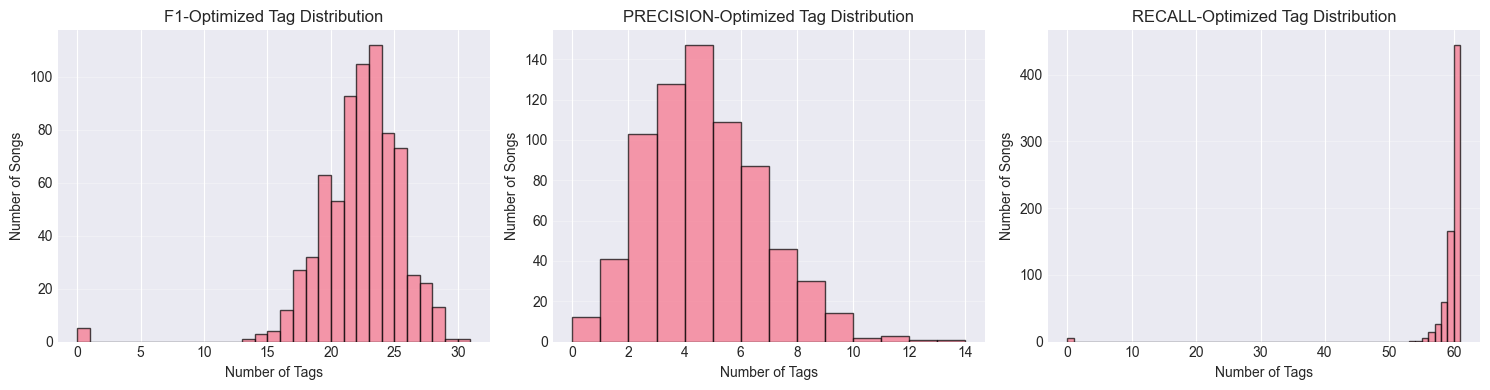

In [30]:
# Visualize tag count distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, metric in enumerate(METRICS):
    col_name = f"all_tags_{metric}"
    tag_counts = results_df.select(pl.col(col_name).list.len()).to_series().to_list()
    
    axes[idx].hist(tag_counts, bins=range(0, max(tag_counts) + 2), edgecolor='black', alpha=0.7)
    axes[idx].set_xlabel('Number of Tags')
    axes[idx].set_ylabel('Number of Songs')
    axes[idx].set_title(f'{metric.upper()}-Optimized Tag Distribution')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

/var/folders/2y/wcq7n_b14cqd36yz8rymh1540000gn/T/ipykernel_59767/3635890849.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[idx].boxplot(data_for_plot, labels=labels)
/var/folders/2y/wcq7n_b14cqd36yz8rymh1540000gn/T/ipykernel_59767/3635890849.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[idx].boxplot(data_for_plot, labels=labels)
/var/folders/2y/wcq7n_b14cqd36yz8rymh1540000gn/T/ipykernel_59767/3635890849.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[idx].boxplot(data_for_plot, labels=labels)


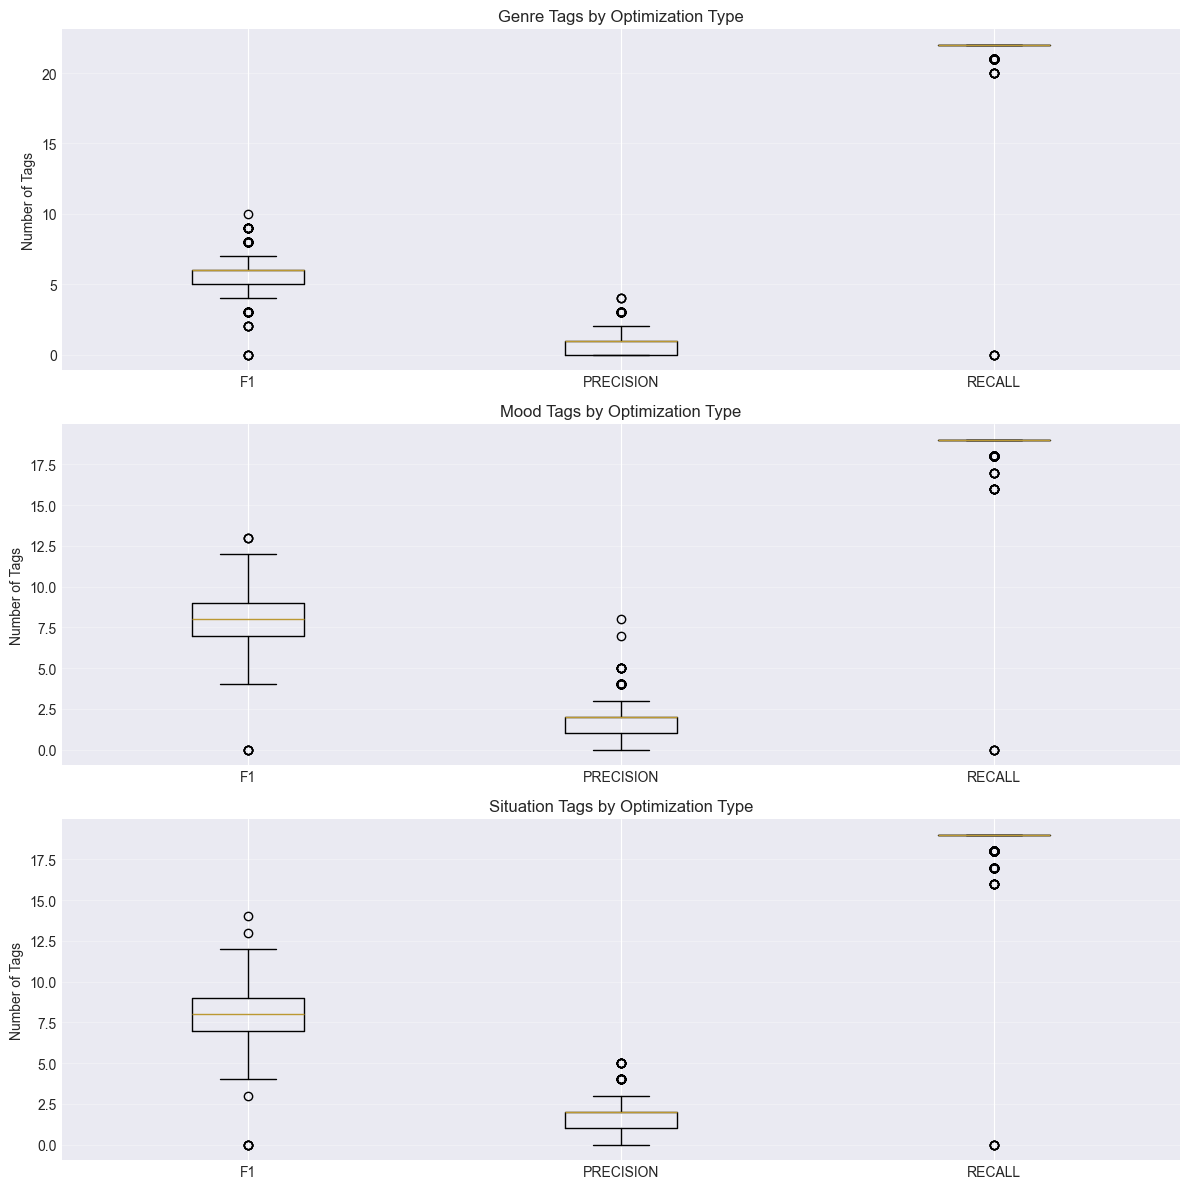

In [31]:
# Visualize predictions by tag group and optimization type
fig, axes = plt.subplots(len(TAG_GROUPS), 1, figsize=(12, 4 * len(TAG_GROUPS)))

if len(TAG_GROUPS) == 1:
    axes = [axes]

for idx, tag_group in enumerate(TAG_GROUPS):
    data_for_plot = []
    labels = []
    
    for metric in METRICS:
        col_name = f"{tag_group}_{metric}"
        tag_counts = results_df.select(pl.col(col_name).list.len()).to_series().to_list()
        data_for_plot.append(tag_counts)
        labels.append(metric.upper())
    
    axes[idx].boxplot(data_for_plot, labels=labels)
    axes[idx].set_ylabel('Number of Tags')
    axes[idx].set_title(f'{tag_group} Tags by Optimization Type')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Export Results

Save the complete results to a CSV file for further analysis.

In [32]:
# Convert lists to comma-separated strings for CSV export
export_df = results_df.clone()

for tag_group in TAG_GROUPS:
    for metric in METRICS:
        col_name = f"{tag_group}_{metric}"
        export_df = export_df.with_columns(
            pl.col(col_name).list.join(", ").alias(col_name)
        )

for metric in METRICS:
    col_name = f"all_tags_{metric}"
    export_df = export_df.with_columns(
        pl.col(col_name).list.join(", ").alias(col_name)
    )

# Save to CSV
output_path = "../data/full_inference_results.csv"
export_df.write_csv(output_path)

print(f"Results exported to: {output_path}")
print(f"Exported {len(export_df)} songs with {len(export_df.columns)} columns")

Results exported to: ../data/full_inference_results.csv
Exported 724 songs with 15 columns


## Summary

Inference complete! The notebook has:

1. ✓ Loaded 9 models (3 tag groups × 3 optimization types)
2. ✓ Applied all models to the inference dataset
3. ✓ Organized predictions by tag group and optimization type
4. ✓ Created combined tag columns for each optimization type
5. ✓ Generated statistics and visualizations
6. ✓ Exported results to CSV

You can now use the predictions based on your needs:
- **F1-optimized**: Balanced precision and recall
- **Precision-optimized**: Fewer but more confident predictions
- **Recall-optimized**: More comprehensive tag coverage

# Export For Database
Selected: `precision_df`

Create a dataframe to write back to the database. 

In [57]:
from nbutils import display_polars
from datetime import datetime

tags_df = pl.read_csv("../data/unique_tags.csv")

SELECTED_DF = precision_df

export_df = (
    SELECTED_DF
    .select(["song_id", "song_title", "artist_name", "all_tags_precision"])
    .explode(["all_tags_precision"])
    .join(
        tags_df,
        left_on="all_tags_precision",
        right_on="TagName", 
        how="left"
    )
    .rename(
        {
            "all_tags_precision": "tag",
            "TagID": "tag_id",
            "UUID": "tag_uuid",
            "TagGroup": "tag_group"
        }
    )
)

# Create datetime string with date and time up to minutes
current_dt_str = datetime.now().strftime("%Y%m%d_%H%M")

export_df.write_parquet(f"../data/full_inference_results_{current_dt_str}.parquet")

display_polars(export_df)

shape: (50, 7)
┌───────────┬───────────────┬───────────────┬──────────────┬────────────┬──────────────┬───────────┐
│ song_id   ┆ song_title    ┆ artist_name   ┆ tag          ┆ tag_id     ┆ tag_uuid     ┆ tag_group │
│ ---       ┆ ---           ┆ ---           ┆ ---          ┆ ---        ┆ ---          ┆ ---       │
│ str       ┆ str           ┆ str           ┆ str          ┆ i64        ┆ str          ┆ str       │
╞═══════════╪═══════════════╪═══════════════╪══════════════╪════════════╪══════════════╪═══════════╡
│ 161119069 ┆ Good          ┆ Session       ┆ Ambient      ┆ 2484825285 ┆ 22a59e2a-b3a ┆ Genre     │
│           ┆ Intentions    ┆ Victim        ┆              ┆            ┆ 6-470e-ad4b- ┆           │
│           ┆               ┆               ┆              ┆            ┆ 92eddadcea7b ┆           │
│ 161119069 ┆ Good          ┆ Session       ┆ Minimal      ┆ 2333129259 ┆ da7ccc4f-510 ┆ Mood      │
│           ┆ Intentions    ┆ Victim        ┆              ┆            ┆ 2-